In [72]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import rc
from scipy.optimize import curve_fit


_dpi = 100


def colormap(num_colors, name = 'rainbow') :
    cmap = mpl.cm.get_cmap(name = name, lut = num_colors)
    return cmap(range(num_colors))

#(10,10), size = 25

rc('text', usetex=True)
rc('font', family='serif', size = 15)

[4.84944936e-05] [3.7500000000000003e-05, 1.4e-08]


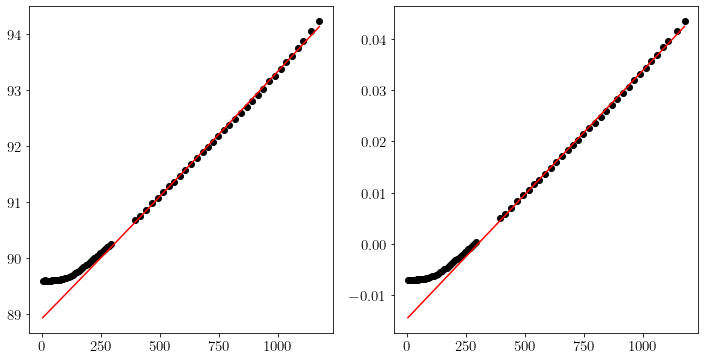

In [73]:



TV1 = np.loadtxt("Fig20.csv", delimiter = ",", skiprows = 1)
TV2 = np.loadtxt("Fig20-2.csv", delimiter = ",", skiprows = 1)
TV = np.concatenate([TV1, TV2], axis = 0)

Tr = 300
Vr = 90.22

def fit1(T : 'K', a0) -> "o/" :  
    return a0 * (T - Tr)

def fit2(T : 'K', a0 : "K-1", b0 : "K-2") -> "o/" :  
    return a0 * (T - Tr)  + b0 / 2 * (T - Tr)**2 

lnV = np.log(V / Vr)
T, V = TV.T

mask = T > Tr


a0, err_a0 = curve_fit(fit1, T[mask], np.log(V[mask]/Vr))
a1, err_a0 = curve_fit(fit2, T[mask], np.log(V[mask]/Vr))
a1 = [0.375*10**(-4), 1.4*10**(-8)]
print(a0, a1)


fig = plt.figure(figsize = (12,6))
ax = fig.subplots(ncols = 2)
ax[0].plot(T, V, ls = 'none', marker = "o", color = 'black', label = 'points exp.')
ax[0].plot(T, Vr*np.exp(fit1(T, a0)), color = 'red', label = 'modèle 1')
#ax[0].plot(T, Vr*np.exp(fit2(T, *a1)), color = 'gray', label = 'modèle 2')

ax[1].plot(T, np.log(V/90.22), ls = 'none', marker = "o", color = 'black')
ax[1].plot(T, fit1(T, a0), ls = '-', color = 'red')
#ax[1].plot(T, fit2(T, a1[0], a1[1]), ls = '-', color = 'blue')

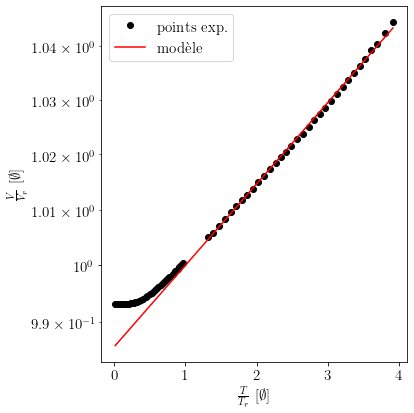

In [86]:
fig = plt.figure(figsize = (6,6))
ax = fig.subplots(ncols = 1)
ax.plot(T/Tr, V/Vr, ls = 'none', marker = "o", color = 'black', label = 'points exp.')
ax.plot(T/Tr, np.exp(fit1(T, a0)), color = 'red', label = 'modèle')

ax.set_yscale('log')
ax.set_ylabel("$\\frac{V}{V_r}$ [$\emptyset$]")
ax.set_xlabel("$\\frac{T}{T_r}$ [$\emptyset$]")

ax.legend()

fig.tight_layout()

fig.savefig("Fig20.pdf", dpi = _dpi)